In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Added OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [24]:
# Evaluation

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score, # Added recall_score
    precision_score # Added precision_score
)

In [3]:
# Handle imbalance

from imblearn.over_sampling import SMOTE

# Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load dataset

file_path = "Vehicle Collision.xlsx"
df = pd.read_excel(file_path)

df.head()

,UNIQUE_ID,COLLISION_ID,CRASH_DATE,CRASH_TIME,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,...,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,PERSON_SEX
0,10253606,4230743.0,10/24/2019,19:15:00,84bcb3a7-d201-4c61-9e30-fe29268c1074,Occupant,Injured,19143343.0,27.0,Not Ejected,...,Back,Driver,Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Driver,NaN,NaN,M
1,10248708,4229547.0,10/26/2019,01:15:00,a8904763-2870-42f3-865c-b53d8e5156e2,Pedestrian,Injured,NaN,24.0,NaN,...,Shoulder - Upper Arm,NaN,NaN,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Crossing With Signal,None Visible,Pedestrian,Unspecified,Unspecified,F
2,10254556,4230715.0,10/26/2019,08:50:00,1a085543-ae9d-4a69-8cd0-fb7b33380a8b,Bicyclist,Injured,19143832.0,42.0,Not Ejected,...,Knee-Lower Leg Foot,Driver,Unknown,NaN,NaN,None Visible,Driver,NaN,NaN,M
3,10250834,4230376.0,10/26/2019,19:40:00,f58fc41f-497e-4f30-bf49-a9a80adec8b2,Bicyclist,Injured,19141949.0,36.0,Not Ejected,...,Back,Driver,NaN,NaN,NaN,Internal,Driver,NaN,NaN,M
4,10252474,4229773.0,10/26/2019,16:50:00,4bf13d12-8d7a-4cb0-997f-dd6a8b1adca6,Occupant,Injured,19142773.0,50.0,Not Ejected,...,Head,"Front passenger, if two or more persons, inclu...",Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Passenger,NaN,NaN,F


In [5]:
df.shape

(230660, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230660 entries, 0 to 230659
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   UNIQUE_ID              230660 non-null  object 
 1   COLLISION_ID           230656 non-null  float64
 2   CRASH_DATE             230656 non-null  object 
 3   CRASH_TIME             230656 non-null  object 
 4   PERSON_ID              230653 non-null  object 
 5   PERSON_TYPE            230656 non-null  object 
 6   PERSON_INJURY          230656 non-null  object 
 7   VEHICLE_ID             181937 non-null  float64
 8   PERSON_AGE             229663 non-null  float64
 9   EJECTION               102787 non-null  object 
 10  EMOTIONAL_STATUS       126918 non-null  object 
 11  BODILY_INJURY          126959 non-null  object 
 12  POSITION_IN_VEHICLE    102906 non-null  object 
 13  SAFETY_EQUIPMENT       90120 non-null   object 
 14  PED_LOCATION           26292 non-nul

In [7]:
# FIX COLUMN NAMES

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Cleaned Columns:")
print(df.columns.tolist())

Cleaned Columns:
['unique_id', 'collision_id', 'crash_date', 'crash_time', 'person_id', 'person_type', 'person_injury', 'vehicle_id', 'person_age', 'ejection', 'emotional_status', 'bodily_injury', 'position_in_vehicle', 'safety_equipment', 'ped_location', 'ped_action', 'complaint', 'ped_role', 'contributing_factor_1', 'contributing_factor_2', 'person_sex']


In [8]:
# AUTO-DETECT TARGET COLUMN

possible_targets = [
    'accident_severity',
    'severity',
    'injury_severity',
    'collision_severity',
    'crash_severity',
    'person_injury' # Added 'person_injury' as a possible target
]

target_col = None
for col in df.columns:
    if col in possible_targets:
        target_col = col
        break

if target_col is None:
    raise ValueError(
        "❌ Target column not found. Available columns:\n"
        + ", ".join(df.columns)
    )

print(f"\n✅ Detected Target Column: {target_col}")


✅ Detected Target Column: person_injury



Target Value Counts:
person_injury
Injured    229633
Killed       1023
Name: count, dtype: int64


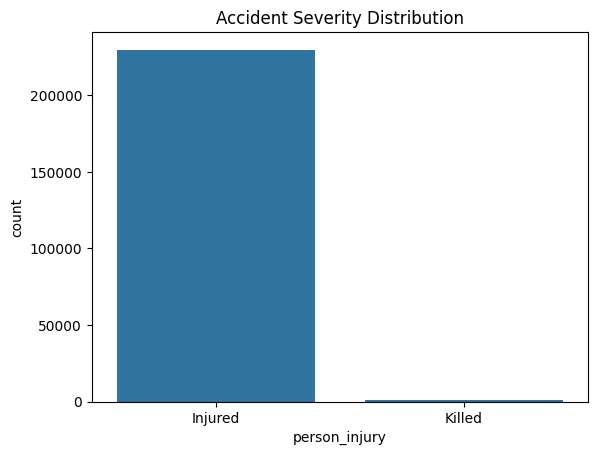

In [9]:
# Target Distribution (EDA)

print("\nTarget Value Counts:")
print(df[target_col].value_counts())

sns.countplot(x=target_col, data=df)
plt.title("Accident Severity Distribution")
plt.show()

In [10]:
# Feature / Target Split

X = df.drop(target_col, axis=1)
y = df[target_col]

# Safe target encoding
if y.dtype == 'object':
    y = y.str.lower()

    # Map 'killed' to 1 and 'injured' to 0 for binary classification
    if 'killed' in y.unique() and 'injured' in y.unique():
        y = y.map({'killed': 1, 'injured': 0})
    else:
        print("⚠️ Unknown target labels or missing expected labels for mapping:", y.unique())


In [11]:
# Identify Feature Types

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

In [12]:
# Preprocessing Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [13]:
# Train-Test Split.

# Drop rows where 'y' is NaN before splitting
non_nan_mask = y.notna()
X_filtered = X[non_nan_mask]
y_filtered = y[non_nan_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered
)

In [14]:
# Preprocess + Handle Class Imbalance

# Convert all categorical features to string type to avoid mixed types for OneHotEncoder
# This ensures all entries are uniformly string-formatted before one-hot encoding.
for col in categorical_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

In [15]:
# Evaluation Function

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Ensure y_test is numerical for metrics like roc_auc_score and roc_curve
    if y_test.dtype == 'object':
        if 'killed' in y_test.unique() and 'injured' in y_test.unique():
            y_test_numerical = y_test.map({'killed': 1, 'injured': 0})
        else:
            # Fallback if other labels are present, or raise an error
            print("⚠️ Warning: y_test contains unexpected string labels for numerical conversion.")
            y_test_numerical = y_test # Proceed with original if conversion not possible
    else:
        y_test_numerical = y_test

    print("Accuracy:", accuracy_score(y_test_numerical, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test_numerical, y_prob))
    print("\nClassification Report:\n", classification_report(y_test_numerical, y_pred))

    cm = confusion_matrix(y_test_numerical, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test_numerical, y_prob)
    plt.plot(fpr, tpr, label='ROC Curve')
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-AUC Curve")
    plt.legend()
    plt.show()

Accuracy: 0.9936486603659065
ROC-AUC: 0.9044248906137895

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     45927
         1.0       0.33      0.40      0.36       205

    accuracy                           0.99     46132
   macro avg       0.66      0.70      0.68     46132
weighted avg       0.99      0.99      0.99     46132



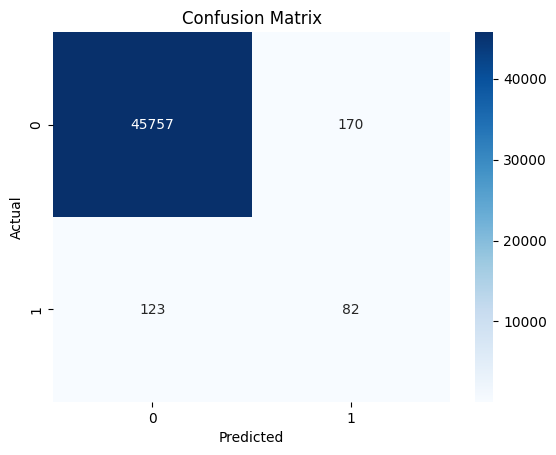

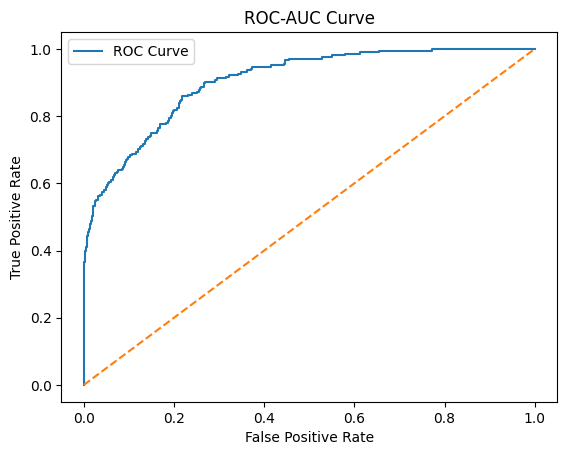

In [16]:
# Logistic Regression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

# Ensure y_train_resampled is numerical before fitting
# This addresses the TypeError caused by fitting with string labels and predicting strings,
# which then mismatch with numerical y_test_numerical in evaluate_model.
if y_train_resampled.dtype == 'object':
    if 'killed' in y_train_resampled.unique() and 'injured' in y_train_resampled.unique():
        y_train_resampled_numerical = y_train_resampled.map({'killed': 1, 'injured': 0})
    else:
        print("⚠️ Warning: y_train_resampled contains unexpected string labels for numerical conversion.")
        y_train_resampled_numerical = y_train_resampled # Fallback
else:
    y_train_resampled_numerical = y_train_resampled

lr.fit(X_train_resampled, y_train_resampled_numerical)
evaluate_model(lr, X_test_processed, y_test)

Accuracy: 0.8233113673805601
ROC-AUC: 0.8162809272615555

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.82      0.90     45927
         1.0       0.01      0.56      0.03       205

    accuracy                           0.82     46132
   macro avg       0.51      0.69      0.47     46132
weighted avg       0.99      0.82      0.90     46132



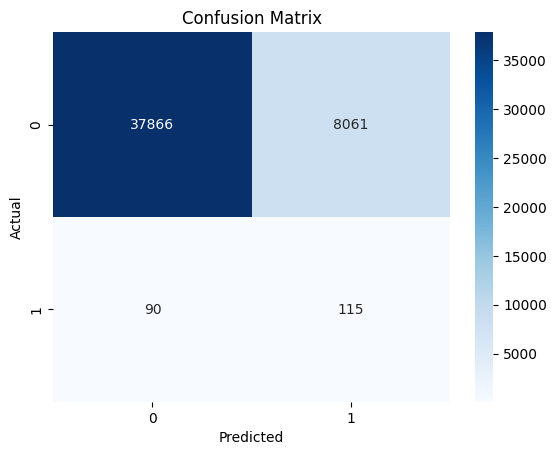

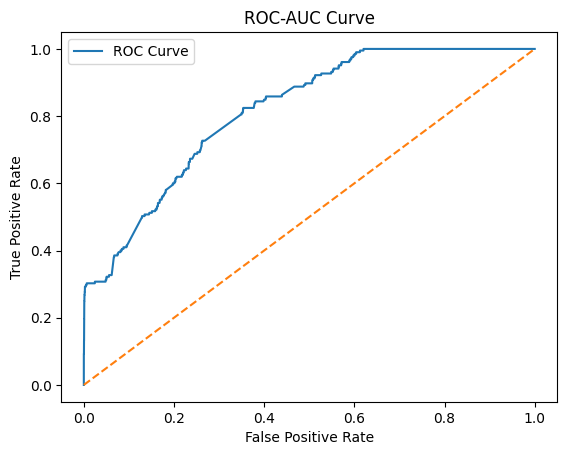

In [17]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_resampled, y_train_resampled)
evaluate_model(rf, X_test_processed, y_test)

Accuracy: 0.8936313188242435
ROC-AUC: 0.9005093448935664

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.89      0.94     45927
         1.0       0.03      0.70      0.06       205

    accuracy                           0.89     46132
   macro avg       0.51      0.80      0.50     46132
weighted avg       0.99      0.89      0.94     46132



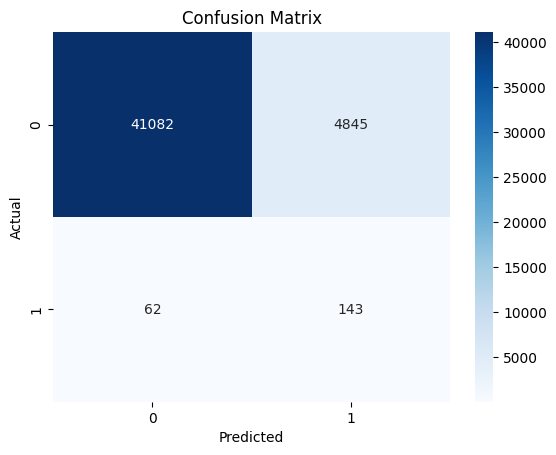

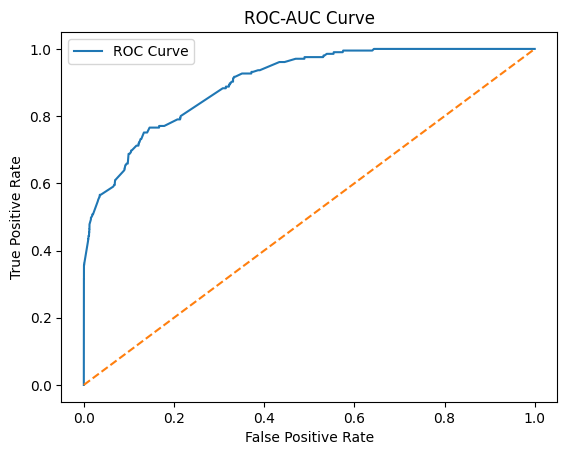

In [18]:
# Gradient Boosting

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_resampled, y_train_resampled)
evaluate_model(gb, X_test_processed, y_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best Parameters (Fast Search): {'max_depth': 12, 'min_samples_split': 6, 'n_estimators': 149}
Accuracy: 0.8256307985779936
ROC-AUC: 0.8189338117171099

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.83      0.90     45927
         1.0       0.01      0.57      0.03       205

    accuracy                           0.83     46132
   macro avg       0.51      0.70      0.47     46132
weighted avg       0.99      0.83      0.90     46132



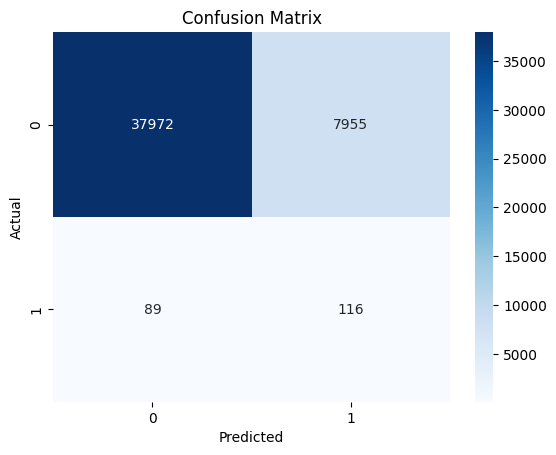

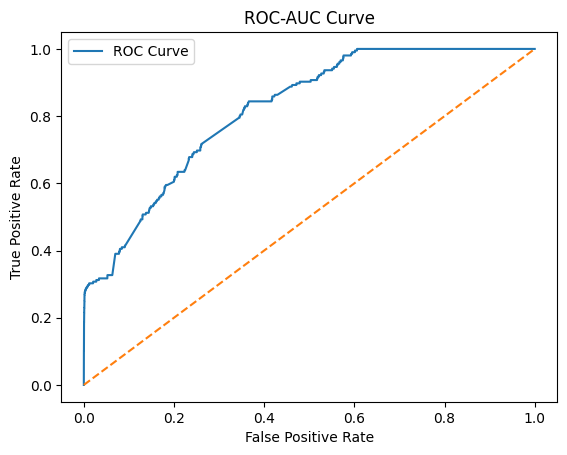

In [20]:
# Hyperparameter Tuning (Random Forest)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 🔶 CHANGED: lighter & randomized parameter search
param_dist = {
    'n_estimators': randint(50, 150),        #  reduced range
    'max_depth': randint(5, 15),             #  reduced depth
    'min_samples_split': randint(2, 10)
}

# 🔶 CHANGED: base model for faster tuning
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# 🔶 CHANGED: RandomizedSearch instead of GridSearch
random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=10,              # 🔶 KEY CHANGE → limits total models
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 🔶 SAME DATA (no other pipeline changes)
random_search.fit(X_train_resampled, y_train_resampled)

best_model = random_search.best_estimator_

print("\n✅ Best Parameters (Fast Search):", random_search.best_params_)

evaluate_model(best_model, X_test_processed, y_test)


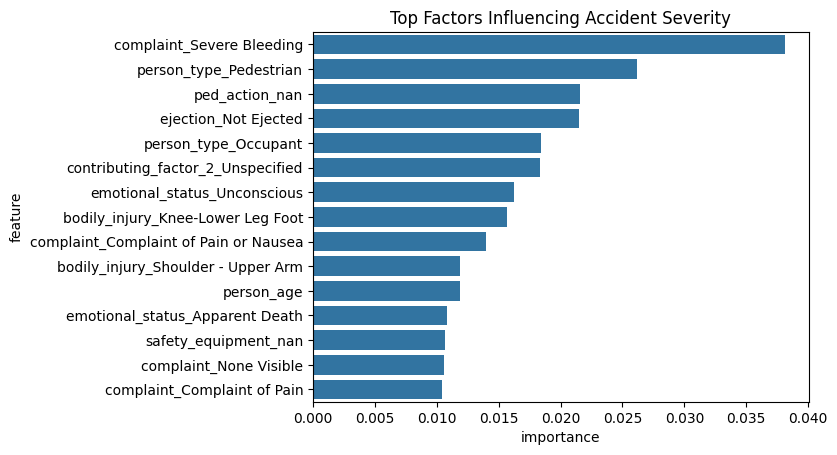

In [21]:
# Feature Importance

feature_names = (
    numerical_features.tolist() +
    list(
        preprocessor
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False).head(15)

sns.barplot(x='importance', y='feature', data=importance_df)
plt.title("Top Factors Influencing Accident Severity")
plt.show()

    threshold  recall_fatal  precision_fatal
0        0.10      1.000000         0.004444
1        0.15      1.000000         0.004444
2        0.20      1.000000         0.004444
3        0.25      1.000000         0.004444
4        0.30      1.000000         0.004444
5        0.35      1.000000         0.004444
6        0.40      1.000000         0.004547
7        0.45      0.970732         0.007480
8        0.50      0.565854         0.014372
9        0.55      0.268293         0.410448
10       0.60      0.000000         0.000000
11       0.65      0.000000         0.000000
12       0.70      0.000000         0.000000
13       0.75      0.000000         0.000000
14       0.80      0.000000         0.000000
15       0.85      0.000000         0.000000


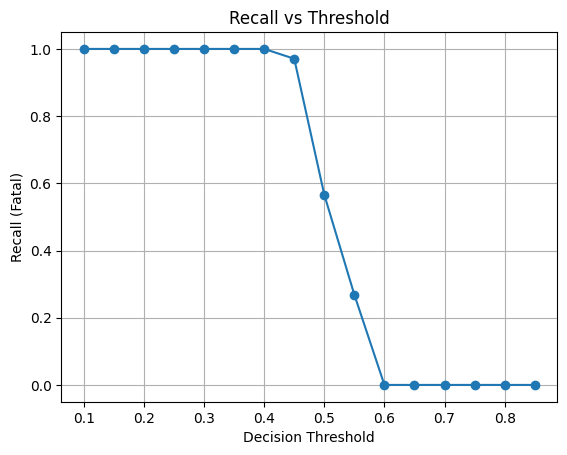


Optimized Threshold = 0.3
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     45927
         1.0       0.00      1.00      0.01       205

    accuracy                           0.00     46132
   macro avg       0.00      0.50      0.00     46132
weighted avg       0.00      0.00      0.00     46132



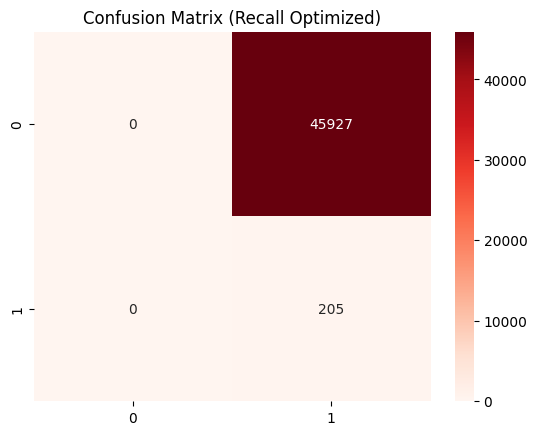

In [25]:
# Recall-Focused Threshold Tuning

y_prob = best_model.predict_proba(X_test_processed)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    results.append((t, recall, precision))

threshold_df = pd.DataFrame(
    results,
    columns=['threshold', 'recall_fatal', 'precision_fatal']
)

print(threshold_df)

plt.plot(threshold_df['threshold'], threshold_df['recall_fatal'], marker='o')
plt.xlabel("Decision Threshold")
plt.ylabel("Recall (Fatal)")
plt.title("Recall vs Threshold")
plt.grid(True)
plt.show()

# Choose recall-optimized threshold
optimal_threshold = 0.30
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

print(f"\nOptimized Threshold = {optimal_threshold}")
print(classification_report(y_test, y_pred_opt))

sns.heatmap(confusion_matrix(y_test, y_pred_opt),
            annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix (Recall Optimized)")
plt.show()